In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/dataset.csv')

In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Limpeza de Dados e Revisão de EDA
Nesta etapa, verificamos a integridade do dataset tratando valores nulos e duplicados, além de analisar a distribuição estatística das variáveis numéricas.

In [9]:
# 1. Verificação de Valores Ausentes
print("Valores ausentes por coluna:")
display(df.isnull().sum())

# 2. Verificação de Duplicatas
print(f"\nTotal de linhas duplicadas: {df.duplicated().sum()}")

# Remover duplicatas se existirem
if df.duplicated().any():
    df = df.drop_duplicates()
    print("Duplicatas removidas.")

Valores ausentes por coluna:


,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0



Total de linhas duplicadas: 0


In [10]:
# 3. Resumo Estatístico para EDA
print("Resumo estatístico das variáveis numéricas:")
display(df.describe())

# 4. Verificação de tipos de dados
print("\nInformações dos tipos de dados:")
display(df.info())

Resumo estatístico das variáveis numéricas:


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000



Informações dos tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  

None

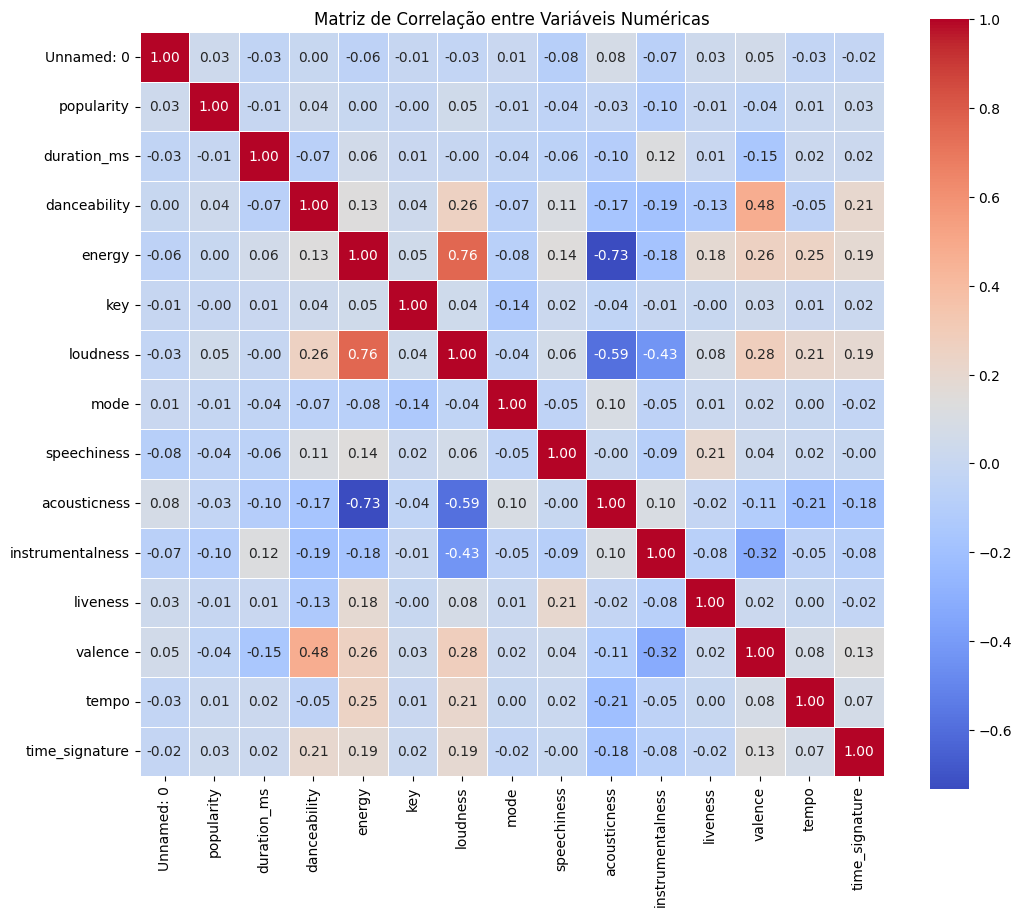

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas as colunas numéricas para o cálculo de correlação
corr = df.select_dtypes(include=['float64', 'int64']).corr()

# Configurar o tamanho da figura
plt.figure(figsize=(12, 10))

# Criar o heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)

plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

/tmp/ipykernel_1298/3553474167.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_popularity.head(50), x='popularity', y='track_genre', palette='viridis')


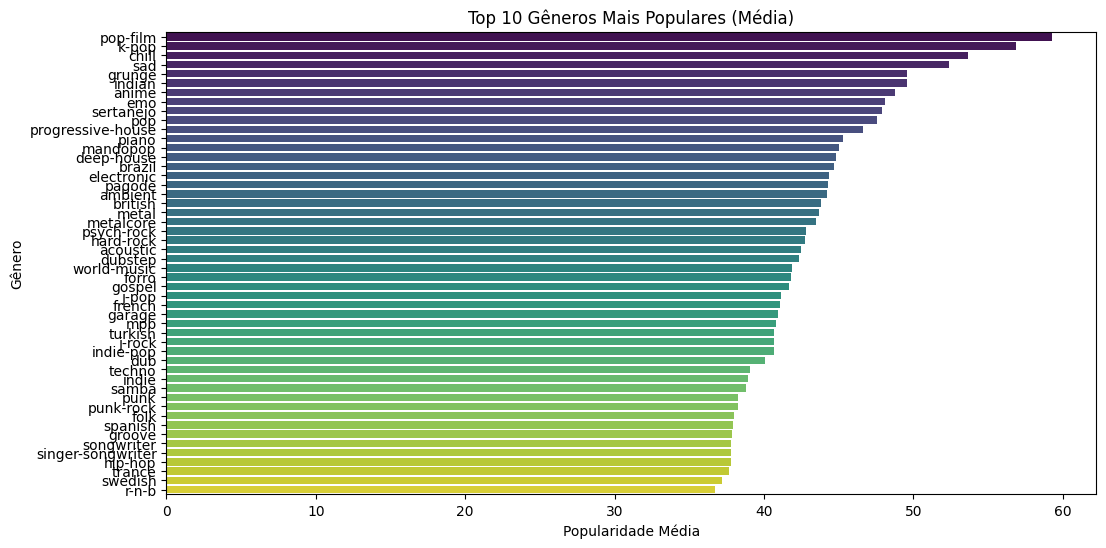

,track_genre,popularity
0,pop-film,59.283
1,k-pop,56.896
2,chill,53.651
3,sad,52.379
4,grunge,49.594
5,indian,49.539
6,anime,48.772
7,emo,48.128
8,sertanejo,47.866
9,pop,47.576


In [20]:
# Agrupando por gênero e calculando a popularidade média
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).reset_index()

# Visualizando os 10 gêneros mais populares
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_popularity.head(50), x='popularity', y='track_genre', palette='viridis')
plt.title('Top 10 Gêneros Mais Populares (Média)')
plt.xlabel('Popularidade Média')
plt.ylabel('Gênero')
plt.show()

# Exibindo os valores exatos
display(genre_popularity.head(50))

### Análise das Características Sonoras (Qualidade do Som)
Como não há uma variável temporal clara, vamos observar a distribuição das principais métricas que compõem o perfil sonoro das faixas.

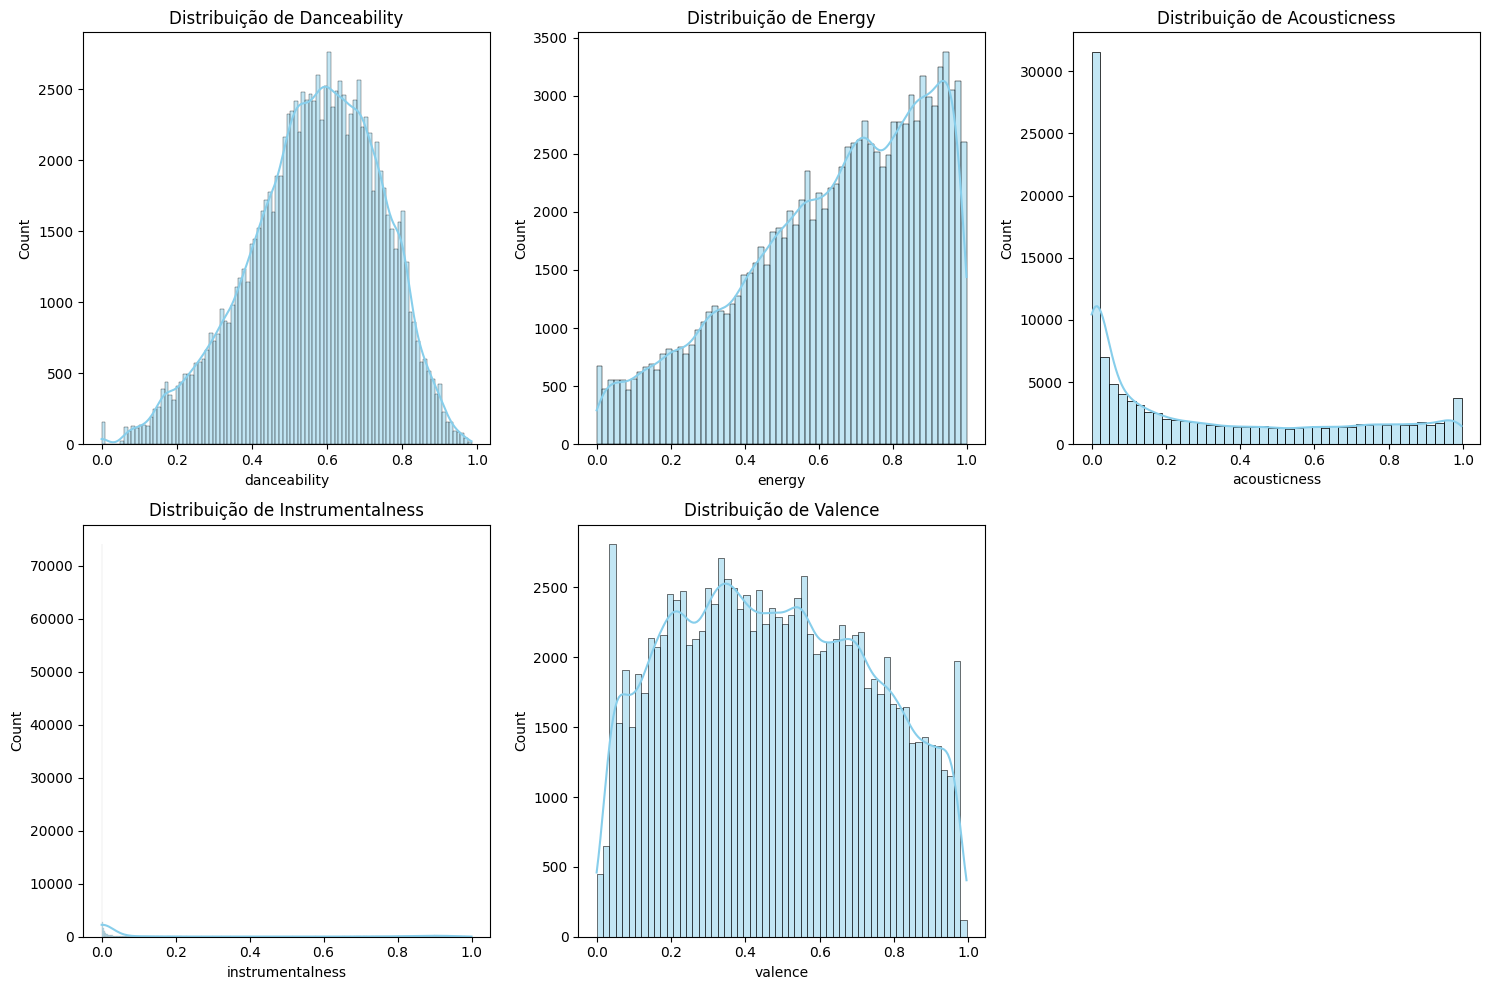

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando colunas de características sonoras
sound_features = ['danceability', 'energy', 'acousticness', 'instrumentalness', 'valence']

# Plotando as distribuições
plt.figure(figsize=(15, 10))
for i, feature in enumerate(sound_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True, color='skyblue')
    plt.title(f'Distribuição de {feature.capitalize()}')

plt.tight_layout()
plt.show()

Colunas disponíveis: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'popularity_bin']
AVISO: Não foi encontrada uma coluna de 'ano' ou 'data'.
Como alternativa, vamos visualizar a variação dessas métricas em relação à Popularidade (como tendência).


/tmp/ipykernel_1298/4265893780.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend_df = df.groupby('popularity_bin')[['danceability', 'energy', 'acousticness', 'valence']].mean().reset_index()


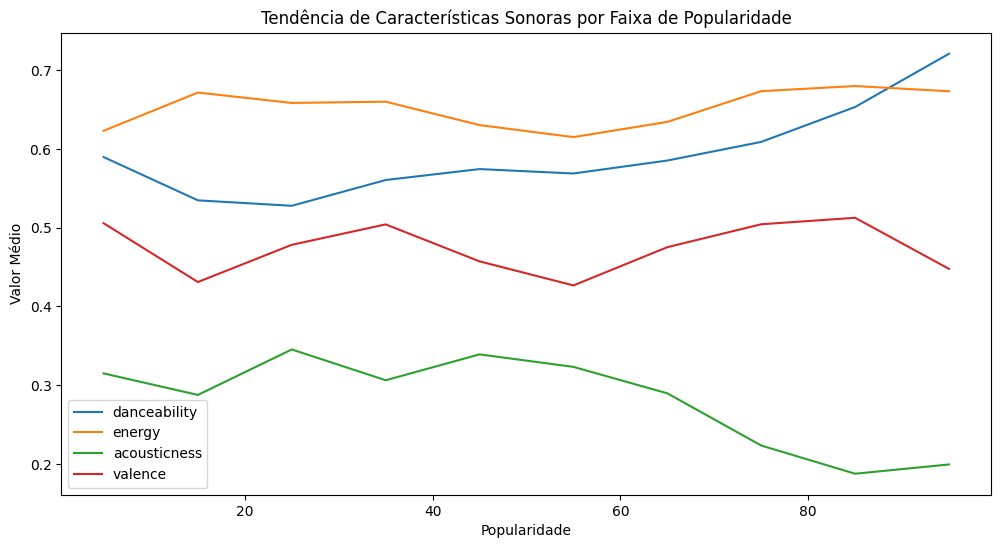

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Verificar se há colunas que possam conter data ou ano
print("Colunas disponíveis:", df.columns.tolist())

# Tentativa de identificar colunas temporais ou criar um cenário para evolução
if 'year' in df.columns:
    year_col = 'year'
elif 'release_date' in df.columns:
    df['year'] = pd.to_datetime(df['release_date']).dt.year
    year_col = 'year'
else:
    year_col = None

if year_col:
    # Agrupar médias por ano
    evolution_df = df.groupby(year_col)[['danceability', 'energy', 'acousticness', 'valence']].mean().reset_index()

    # Plotar a evolução
    plt.figure(figsize=(12, 6))
    for feature in ['danceability', 'energy', 'acousticness', 'valence']:
        sns.lineplot(data=evolution_df, x=year_col, y=feature, label=feature)

    plt.title('Evolução das Características Sonoras ao Longo dos Anos')
    plt.xlabel('Ano')
    plt.ylabel('Valor Médio')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("AVISO: Não foi encontrada uma coluna de 'ano' ou 'data'.")
    print("Como alternativa, vamos visualizar a variação dessas métricas em relação à Popularidade (como tendência).")

    # Binning de popularidade para ver tendências em faixas de sucesso
    df['popularity_bin'] = pd.cut(df['popularity'], bins=10)
    trend_df = df.groupby('popularity_bin')[['danceability', 'energy', 'acousticness', 'valence']].mean().reset_index()
    trend_df['popularity_bin'] = trend_df['popularity_bin'].apply(lambda x: x.mid)

    plt.figure(figsize=(12, 6))
    for feature in ['danceability', 'energy', 'acousticness', 'valence']:
        sns.lineplot(data=trend_df, x='popularity_bin', y=feature, label=feature)

    plt.title('Tendência de Características Sonoras por Faixa de Popularidade')
    plt.xlabel('Popularidade')
    plt.ylabel('Valor Médio')
    plt.legend()
    plt.show()

/tmp/ipykernel_1298/980960559.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=popularity_corr, x='Correlation', y='Feature', palette='RdBu_r')


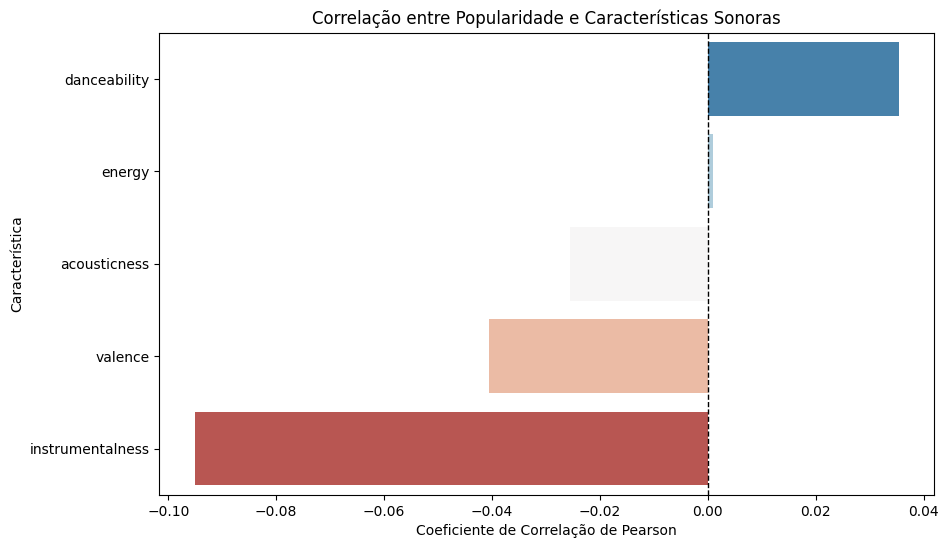

,Feature,Correlation
0,danceability,0.035448
1,energy,0.001056
2,acousticness,-0.025472
3,valence,-0.040534
4,instrumentalness,-0.095139


In [25]:
# Filtrando a correlação especificamente para a Popularidade
popularity_corr = corr['popularity'][sound_features].sort_values(ascending=False).reset_index()
popularity_corr.columns = ['Feature', 'Correlation']

# Visualizando a correlação
plt.figure(figsize=(10, 6))
sns.barplot(data=popularity_corr, x='Correlation', y='Feature', palette='RdBu_r')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Correlação entre Popularidade e Características Sonoras')
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.ylabel('Característica')
plt.show()

display(popularity_corr)

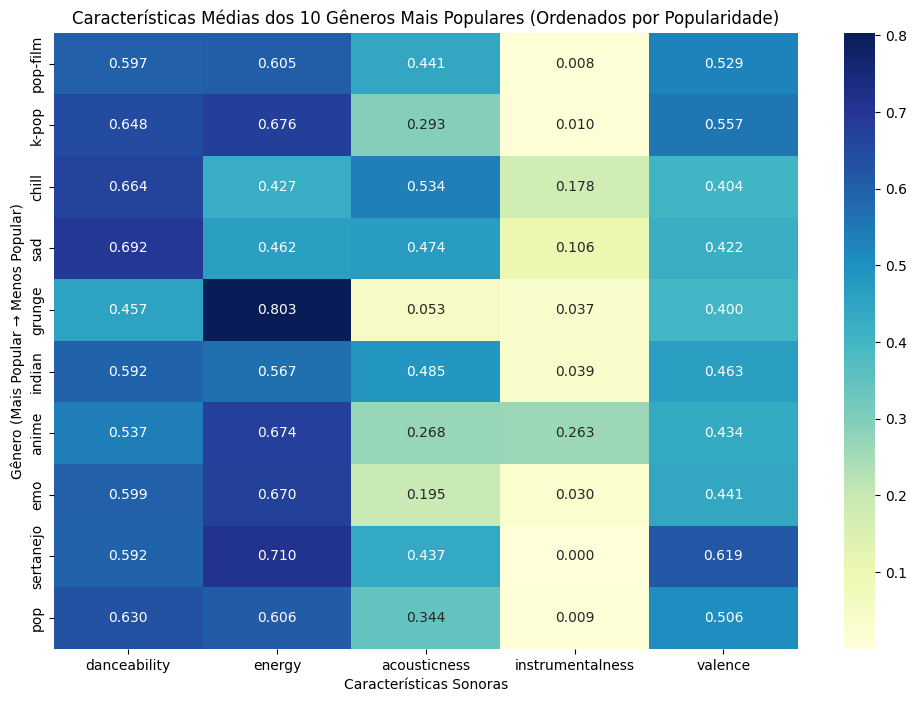

Características dominantes ordenadas por ranking de popularidade:


,danceability,energy,acousticness,instrumentalness,valence
track_genre,,,,,
pop-film,0.597146,0.604562,0.440696,0.008124,0.529253
k-pop,0.647732,0.675654,0.292968,0.009828,0.556915
chill,0.664346,0.426723,0.534097,0.178022,0.403770
sad,0.692378,0.462470,0.473710,0.105740,0.422050
grunge,0.457062,0.803290,0.053441,0.036983,0.400373
indian,0.592273,0.567121,0.484919,0.039408,0.463024
anime,0.537451,0.674108,0.267734,0.262971,0.434463
emo,0.599321,0.669967,0.195081,0.030281,0.441135
sertanejo,0.591647,0.710391,0.436621,0.000160,0.619325


In [28]:
# 1. Identificar os 10 gêneros mais populares e manter a ordem
top_10_genres = genre_popularity.head(10)['track_genre'].tolist()

# 2. Filtrar e calcular médias, garantindo que a ordem siga a lista 'top_10_genres'
top_genres_features = df[df['track_genre'].isin(top_10_genres)].groupby('track_genre')[sound_features].mean()
top_genres_features = top_genres_features.reindex(top_10_genres)

# 3. Visualização comparativa (Heatmap ordenado por Popularidade)
plt.figure(figsize=(12, 8))
sns.heatmap(top_genres_features, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('Características Médias dos 10 Gêneros Mais Populares (Ordenados por Popularidade)')
plt.xlabel('Características Sonoras')
plt.ylabel('Gênero (Mais Popular → Menos Popular)')
plt.show()

# 4. Resumo textual
print("Características dominantes ordenadas por ranking de popularidade:")
display(top_genres_features)

Artistas mais populares e seus respectivos gêneros:


,artists,track_genre,popularity
0,Sam Smith;Kim Petras,pop,100.0
1,Sam Smith;Kim Petras,dance,100.0
2,Bizarrap;Quevedo,hip-hop,99.0
3,Manuel Turizo,reggae,98.0
4,Manuel Turizo,reggaeton,98.0
5,Manuel Turizo,latino,98.0
6,Manuel Turizo,latin,98.0
7,Bad Bunny;Chencho Corleone,reggaeton,97.0
8,Bad Bunny;Chencho Corleone,reggae,97.0
9,Bad Bunny;Chencho Corleone,latin,97.0


/tmp/ipykernel_1298/3486016079.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=top_artists, y='track_genre', palette='magma', order=top_artists['track_genre'].value_counts().index)


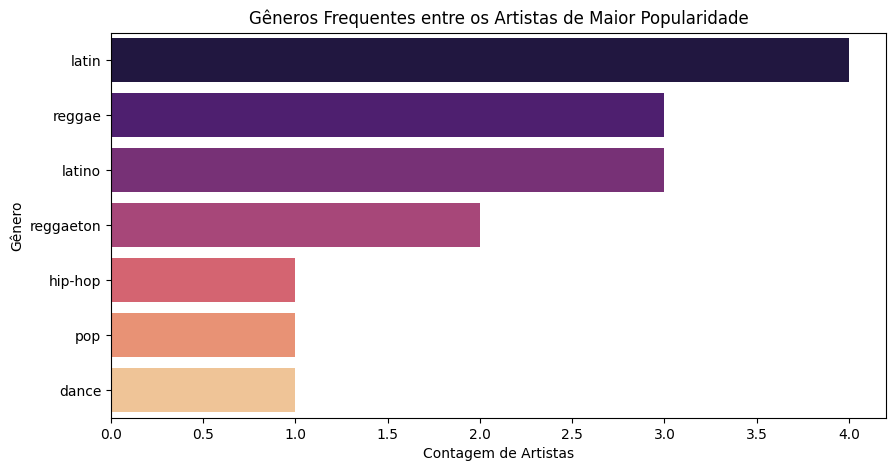

In [29]:
import pandas as pd

# Identificando os artistas com maior popularidade média
top_artists = df.groupby(['artists', 'track_genre'])['popularity'].mean().sort_values(ascending=False).head(15).reset_index()

print("Artistas mais populares e seus respectivos gêneros:")
display(top_artists)

# Resumo por contagem de gênero entre os top artistas
plt.figure(figsize=(10, 5))
sns.countplot(data=top_artists, y='track_genre', palette='magma', order=top_artists['track_genre'].value_counts().index)
plt.title('Gêneros Frequentes entre os Artistas de Maior Popularidade')
plt.xlabel('Contagem de Artistas')
plt.ylabel('Gênero')
plt.show()